In [83]:
import pandas as pd
import glob

In [15]:
metadata = pd.read_csv("../data/SPARK.iWES_v3.2024_08.sample_metadata.tsv", sep = "\t")[["spid", "sfid", "father", "mother", "asd"]]
metadata

,spid,sfid,father,mother,asd
0,SP0000003,SF0000003,0,SP0000002,True
1,SP0000002,SF0000003,0,0,False
2,SP0000017,SF0000017,0,0,True
3,SP0000026,SF0000026,SP0255776,SP0000046,True
4,SP0000046,SF0000026,0,0,False
...,...,...,...,...,...
142352,SP0318144,SF0583492,0,0,True
142353,SP0318143,SF0583492,SP0325663,SP0318140,True
142354,SP0329625,SF0583492,SP0325663,SP0318140,True
142355,SP0318140,SF0583492,0,0,False


In [ ]:
## Adding children as a column to the table

# Group by father and collect children
father_children = metadata.groupby("father")["spid"].apply(list).to_dict()
mother_children = metadata.groupby("mother")["spid"].apply(list).to_dict()

# Function to get children as string
def get_children_string(spid):
    children = father_children.get(spid, []) + mother_children.get(spid, [])
    return ",".join(map(str, children))  # convert numbers to string and join

metadata["children"] = metadata["spid"].apply(get_children_string)
metadata

,spid,sfid,father,mother,asd,children
0,SP0000003,SF0000003,0,SP0000002,True,
1,SP0000002,SF0000003,0,0,False,SP0000003
2,SP0000017,SF0000017,0,0,True,
3,SP0000026,SF0000026,SP0255776,SP0000046,True,
4,SP0000046,SF0000026,0,0,False,"SP0000026,SP0000062"
...,...,...,...,...,...,...
142352,SP0318144,SF0583492,0,0,True,
142353,SP0318143,SF0583492,SP0325663,SP0318140,True,
142354,SP0329625,SF0583492,SP0325663,SP0318140,True,
142355,SP0318140,SF0583492,0,0,False,"SP0318143,SP0329625"


In [29]:
# Affected rows
affected = metadata[metadata["asd"]]
affected

,spid,sfid,father,mother,asd,children
0,SP0000003,SF0000003,0,SP0000002,True,
2,SP0000017,SF0000017,0,0,True,
3,SP0000026,SF0000026,SP0255776,SP0000046,True,
7,SP0000027,SF0000027,SP0000241,SP0000051,True,
8,SP0000034,SF0000027,SP0000241,SP0000051,True,
...,...,...,...,...,...,...
142349,SP0412142,SF0571246,0,SP0424823,True,
142351,SP0360833,SF0572144,0,SP0371087,True,
142352,SP0318144,SF0583492,0,0,True,
142353,SP0318143,SF0583492,SP0325663,SP0318140,True,


In [30]:
# Unaffected individuals
unaffected = metadata[~metadata["asd"]]
unaffected

,spid,sfid,father,mother,asd,children
1,SP0000002,SF0000003,0,0,False,SP0000003
4,SP0000046,SF0000026,0,0,False,"SP0000026,SP0000062"
5,SP0000062,SF0000026,SP0255776,SP0000046,False,
6,SP0000051,SF0000027,0,0,False,"SP0000027,SP0000034,SP0000063"
10,SP0000241,SF0000027,0,0,False,"SP0000027,SP0000034,SP0000063"
...,...,...,...,...,...,...
142346,SP0411615,SF0566626,0,0,False,SP0411602
142348,SP0424823,SF0571246,0,0,False,SP0412142
142350,SP0371087,SF0572144,0,0,False,SP0360833
142355,SP0318140,SF0583492,0,0,False,"SP0318143,SP0329625"


In [ ]:
# Remove rows where parents are both 0 & 0 - because can't distinguish whether person is adopted or not
unaffected_filtered = unaffected[(unaffected["father"] != "0") & (unaffected["mother"] != "0")]
unaffected_filtered

,spid,sfid,father,mother,asd,children
5,SP0000062,SF0000026,SP0255776,SP0000046,False,
13,SP0000036,SF0000033,SP0000684,SP0000067,False,
28,SP0000056,SF0000087,SP0003120,SP0000055,False,
38,SP0001673,SF0000145,SP0007039,SP0000111,False,
50,SP0000201,SF0000164,SP0000231,SP0000131,False,
...,...,...,...,...,...,...
142256,SP0558268,SF0558266,SP0561614,SP0558265,False,
142287,SP0558646,SF0558645,SP0558652,SP0558644,False,
142291,SP0558735,SF0558734,SP0560038,SP0550207,False,
142296,SP0558746,SF0558743,SP0558753,SP0558724,False,


In [45]:
# Get rows where share sfid father mother with affected
aff_unaff_merged = pd.merge(unaffected_filtered, affected, on=["sfid", "father", "mother"], suffixes=("_unaffected", "_affected"))
aff_unaff_merged

,spid_unaffected,sfid,father,mother,asd_unaffected,children_unaffected,spid_affected,asd_affected,children_affected
0,SP0000062,SF0000026,SP0255776,SP0000046,False,,SP0000026,True,
1,SP0000036,SF0000033,SP0000684,SP0000067,False,,SP0000033,True,
2,SP0001673,SF0000145,SP0007039,SP0000111,False,,SP0000145,True,
3,SP0000201,SF0000164,SP0000231,SP0000131,False,,SP0000164,True,
4,SP0000285,SF0000226,SP0000819,SP0001282,False,,SP0000226,True,
...,...,...,...,...,...,...,...,...,...
12206,SP0558646,SF0558645,SP0558652,SP0558644,False,,SP0558653,True,
12207,SP0558646,SF0558645,SP0558652,SP0558644,False,,SP0558645,True,
12208,SP0558735,SF0558734,SP0560038,SP0550207,False,,SP0558734,True,
12209,SP0558746,SF0558743,SP0558753,SP0558724,False,,SP0558743,True,


In [ ]:
# Unique unaffected IDs
len(aff_unaff_merged["spid_unaffected"].unique())

11067

In [47]:
aff_unaff_merged["children_affected"].value_counts()

children_affected
                                 12201
SP0019346                            1
SP0028553                            1
SP0110560,SP0110559,SP0110558        1
SP0117619,SP0117617                  1
SP0340941                            1
SP0425690                            1
SP0435248                            1
SP0440105,SP0440110,SP0440107        1
SP0477985,SP0477984                  1
SP0510996,SP0510997,SP0510994        1
Name: count, dtype: int64

In [48]:
aff_unaff_merged["children_unaffected"].value_counts()

children_unaffected
                       12208
SP0055649                  1
SP0381197,SP0381196        1
SP0476714,SP0476713        1
Name: count, dtype: int64

In [ ]:
# no suspected sibling pairs share children -- they really are siblings! not spouses
aff_unaff_merged[aff_unaff_merged["children_affected"]!= ""]

,spid_unaffected,sfid,father,mother,asd_unaffected,children_unaffected,spid_affected,asd_affected,children_affected
657,SP0020813,SF0019346,SP0026015,SP0023598,False,,SP0019273,True,SP0019346
1042,SP0029050,SF0028553,SP0028277,SP0028365,False,,SP0028528,True,SP0028553
3910,SP0257553,SF0110558,SP0259691,SP0259681,False,,SP0110557,True,"SP0110560,SP0110559,SP0110558"
4069,SP0117695,SF0117617,SP0117911,SP0121640,False,,SP0117616,True,"SP0117619,SP0117617"
7512,SP0341657,SF0340941,SP0341073,SP0341008,False,,SP0340940,True,SP0340941
9554,SP0425896,SF0425690,SP0425718,SP0426673,False,,SP0425687,True,SP0425690
9812,SP0442925,SF0435248,SP0442487,SP0440243,False,,SP0435247,True,SP0435248
9960,SP0449352,SF0440105,SP0449408,SP0449415,False,,SP0449343,True,"SP0440105,SP0440110,SP0440107"
10858,SP0478923,SF0477984,SP0478959,SP0478198,False,,SP0477983,True,"SP0477985,SP0477984"
11519,SP0515462,SF0510994,SP0531343,SP0531436,False,,SP0510993,True,"SP0510996,SP0510997,SP0510994"


In [54]:
all_affected = affected[["spid"]].drop_duplicates()
all_affected

,spid
0,SP0000003
2,SP0000017
3,SP0000026
7,SP0000027
8,SP0000034
...,...
142349,SP0412142
142351,SP0360833
142352,SP0318144
142353,SP0318143


In [81]:
all_affected.to_csv("../data/all_asd_spids.txt", index=None, header=None)

In [55]:
unaff_sibs = aff_unaff_merged[["spid_unaffected"]].drop_duplicates()
unaff_sibs

,spid_unaffected
0,SP0000062
1,SP0000036
2,SP0001673
3,SP0000201
4,SP0000285
...,...
12205,SP0558268
12206,SP0558646
12208,SP0558735
12209,SP0558746


In [80]:
unaff_sibs.to_csv("../data/unaff_sibs_spids_fixed.txt", index=None, header=None)

In [56]:
affected_with_sibs = aff_unaff_merged[["spid_affected"]].drop_duplicates()
affected_with_sibs

,spid_affected
0,SP0000026
1,SP0000033
2,SP0000145
3,SP0000164
4,SP0000226
...,...
12206,SP0558653
12207,SP0558645
12208,SP0558734
12209,SP0558743


76038

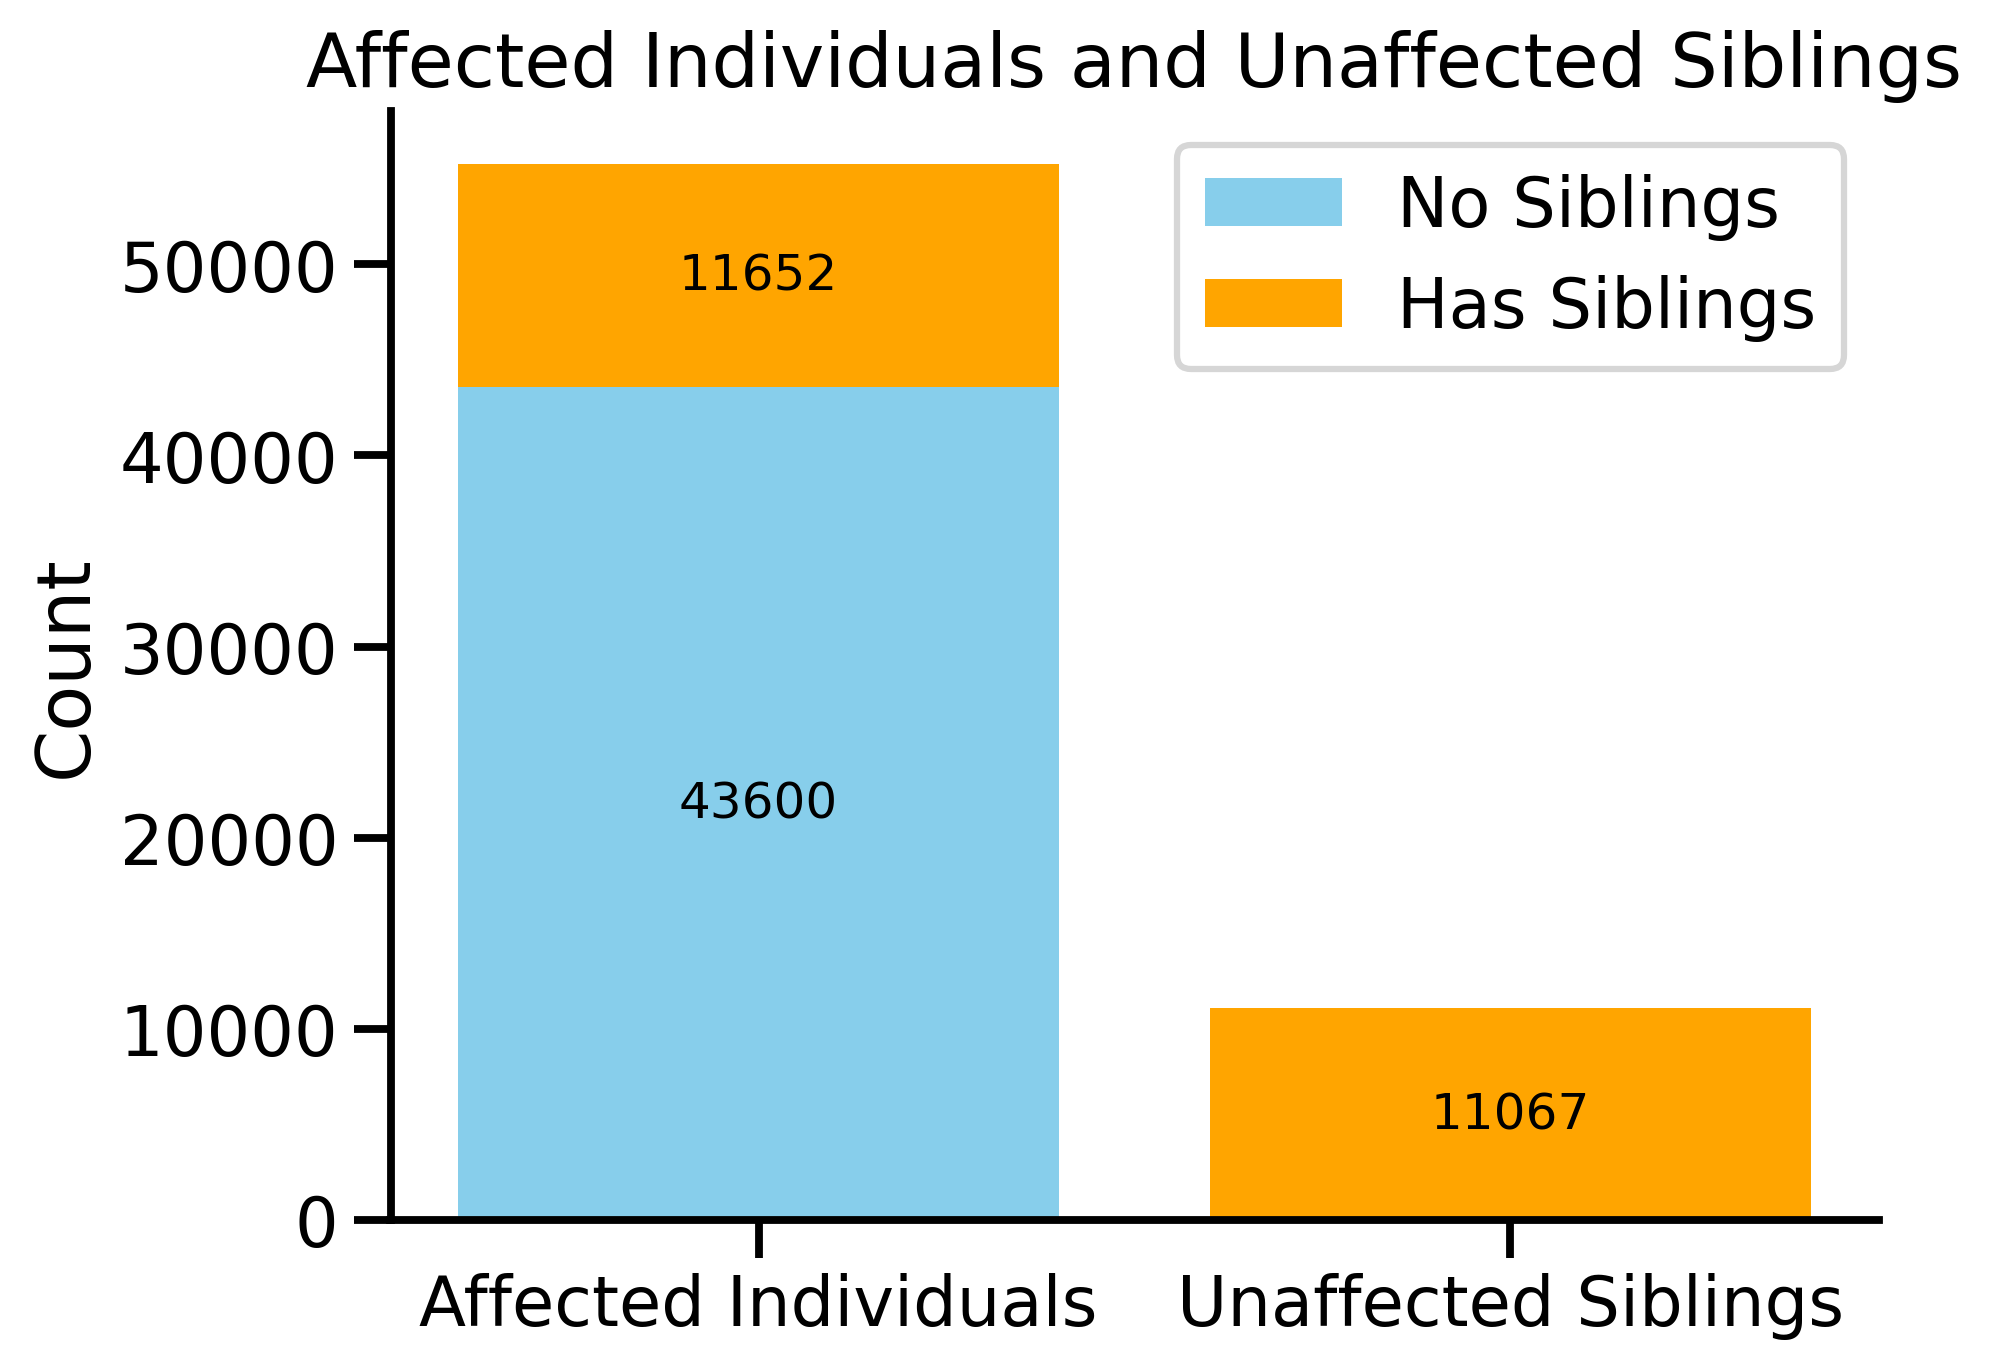

In [79]:
import matplotlib.pyplot as plt

# Data
categories = ['Affected Individuals', 'Unaffected Siblings']
total = [len(all_affected), len(affected_with_sibs)]
with_siblings = [len(affected_with_sibs), len(unaff_sibs)]  # overlapping portion
without_siblings = [total[0] - with_siblings[0], 0]

# Plot
sns.set_context('talk')
fig, ax = plt.subplots(dpi = 300)
ax.bar(categories, without_siblings, label='No Siblings', color='skyblue')
ax.bar(categories, with_siblings, bottom=without_siblings, label='Has Siblings', color='orange')

# Add labels on top of each stacked bar
for i in range(len(categories)):
    # Top of 'No Siblings' segment
    if without_siblings[i] > 0:
        ax.text(i, without_siblings[i]/2, str(without_siblings[i]), ha='center', va='center', color='black', fontsize=12)
    # Top of 'Has Siblings' segment
    if with_siblings[i] > 0:
        ax.text(i, without_siblings[i] + with_siblings[i]/2, str(with_siblings[i]), ha='center', va='center', color='black', fontsize=12)


ax.set_ylabel('Count')
ax.set_title('Affected Individuals and Unaffected Siblings')
ax.legend()
sns.despine()
plt.show()

In [74]:
metadata["asd"].value_counts()

asd
False    87105
True     55252
Name: count, dtype: int64

In [87]:
# Need a bed file of all human TFs to speed up subsetting step
bed_df = []
for path in glob.glob("../soto_analysis/outputs/mutations/cds_bed_format/*"): 
    if "sorted" not in path:
        bed_df.append(pd.read_csv(path, sep = "\t", header = None))
bed_df = pd.concat(bed_df)
bed_df

,0,1,2,3,4
0,7,99506044,99506458,ENST00000326775,1
1,7,99512452,99512591,ENST00000326775,1
2,7,99519826,99519909,ENST00000326775,1
3,7,99520168,99520304,ENST00000326775,1
4,7,99525812,99526418,ENST00000326775,1
...,...,...,...,...,...
0,4,89112974,89114552,ENST00000603357,1
0,19,12017875,12017936,ENST00000344980,-1
1,19,12014844,12016666,ENST00000344980,-1
2,19,12035536,12035539,ENST00000344980,-1


In [91]:
bed_df.to_csv("../data/lambert_TFs.bed", index = None, header = None, sep = "\t")

In [92]:
bed_df[0].value_counts()

0
19    1560
1      936
2      699
12     641
7      580
6      491
11     456
17     445
3      421
16     390
9      382
20     377
8      315
4      263
10     244
15     223
X      210
5      203
18     199
14     153
13     131
21     112
22      80
Y       11
Name: count, dtype: int64